In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("attack_new.csv")

print(df.shape)

df.head()

(2328, 11)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd,Label
0,4.011355,263.252696,3.988677,16,1056,3.988677,0,16,53248,0,ATTACK
1,3.891023,288.356068,4.369031,17,1122,4.369031,0,17,53248,0,ATTACK
2,2.596417,67.015431,1.155438,3,174,1.155438,3,3,65535,0,ATTACK
3,3.674395,377.204995,5.715227,21,1386,5.715227,0,21,53248,0,ATTACK
4,4.266082,1274.706053,10.548322,45,5438,10.548322,0,45,615,45,ATTACK


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2328 entries, 0 to 2327
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flow Duration                2328 non-null   float64
 1   Flow Bytes/s                 2328 non-null   float64
 2   Flow Packets/s               2328 non-null   float64
 3   Total Fwd Packets            2328 non-null   int64  
 4   Total Length of Fwd Packets  2328 non-null   int64  
 5   Fwd Packets/s                2328 non-null   float64
 6   SYN Flag Count               2328 non-null   int64  
 7   ACK Flag Count               2328 non-null   int64  
 8   Init_Win_bytes_forward       2328 non-null   int64  
 9   act_data_pkt_fwd             2328 non-null   int64  
 10  Label                        2328 non-null   object 
dtypes: float64(4), int64(6), object(1)
memory usage: 200.2+ KB


In [4]:
df.isnull().sum()

Flow Duration                  0
Flow Bytes/s                   0
Flow Packets/s                 0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packets/s                  0
SYN Flag Count                 0
ACK Flag Count                 0
Init_Win_bytes_forward         0
act_data_pkt_fwd               0
Label                          0
dtype: int64

In [5]:
print(df.duplicated().sum())

0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,2328.0,3.336432,1.370714,0.007693,2.649565,3.576106,4.480053,4.997871e+00
Flow Bytes/s,2328.0,11921.722760,54782.529126,41.344383,184.802878,277.044285,536.122515,6.409245e+05
Flow Packets/s,2328.0,16.040747,39.008110,0.648938,2.708747,4.088316,7.168808,4.388495e+02
Total Fwd Packets,2328.0,45.081615,112.990598,3.000000,6.000000,13.000000,21.000000,7.670000e+02
Total Length of Fwd Packets,2328.0,45920.167526,226910.089600,162.000000,420.000000,924.000000,1431.000000,2.982162e+06
Fwd Packets/s,2328.0,16.040747,39.008110,0.648938,2.708747,4.088316,7.168808,4.388495e+02
SYN Flag Count,2328.0,24.987543,106.347164,0.000000,0.000000,0.000000,1.000000,7.670000e+02
ACK Flag Count,2328.0,20.482818,45.843071,0.000000,4.000000,12.000000,19.000000,6.140000e+02
Init_Win_bytes_forward,2328.0,43322.187285,24284.274694,0.000000,53248.000000,53248.000000,53248.000000,6.553500e+04
act_data_pkt_fwd,2328.0,31.534364,108.728352,0.000000,0.000000,0.000000,3.000000,7.670000e+02


In [7]:
df.median(numeric_only=True)

Flow Duration                      3.576106
Flow Bytes/s                     277.044285
Flow Packets/s                     4.088316
Total Fwd Packets                 13.000000
Total Length of Fwd Packets      924.000000
Fwd Packets/s                      4.088316
SYN Flag Count                     0.000000
ACK Flag Count                    12.000000
Init_Win_bytes_forward         53248.000000
act_data_pkt_fwd                   0.000000
dtype: float64

In [8]:
df["Label"].value_counts()

Label
ATTACK    2328
Name: count, dtype: int64

In [9]:
features = [

'Flow Duration',

'Flow Bytes/s',

'Flow Packets/s',

'Total Fwd Packets',

'Total Length of Fwd Packets',

'Fwd Packets/s',

'SYN Flag Count',

'ACK Flag Count',

'Init_Win_bytes_forward',

'act_data_pkt_fwd'

]

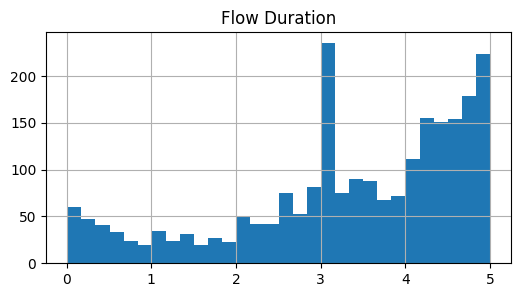

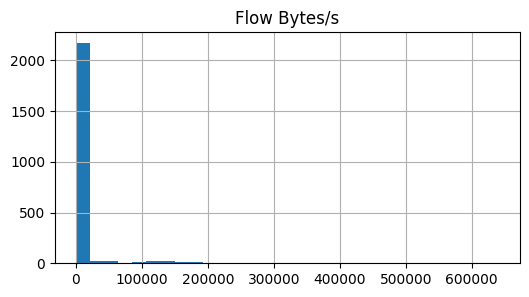

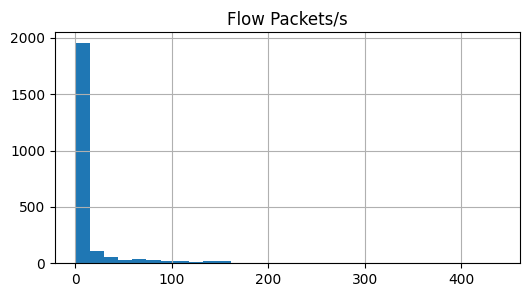

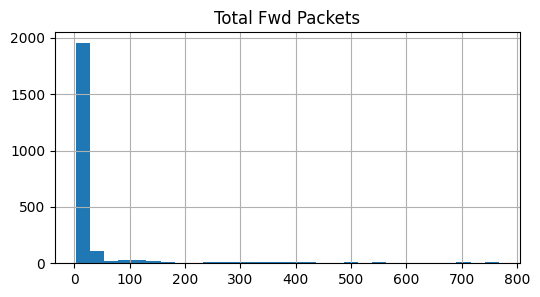

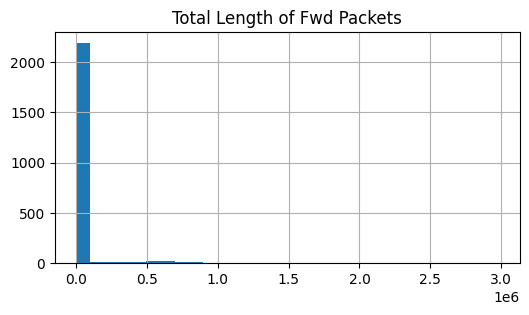

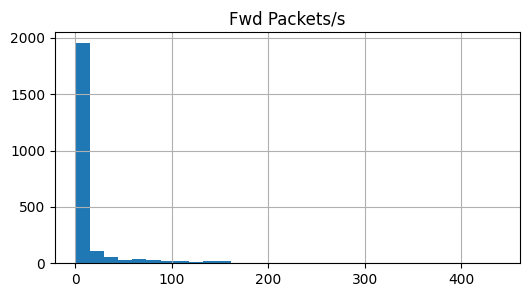

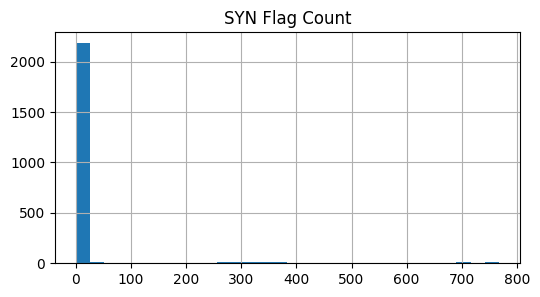

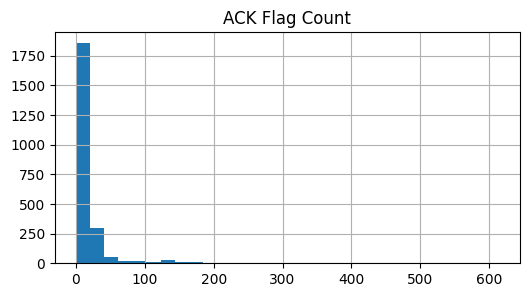

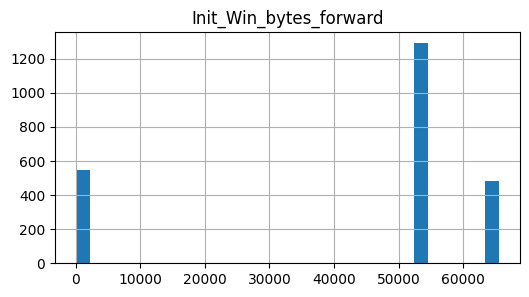

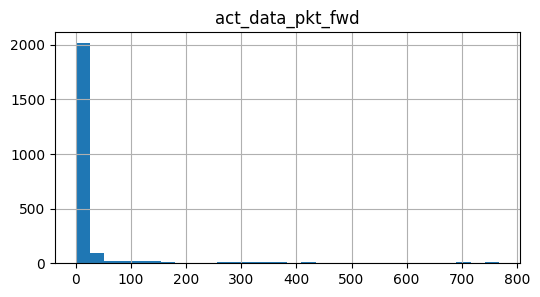

In [10]:
for col in features:

    plt.figure(figsize=(6,3))

    plt.hist(df[col], bins=30)

    plt.title(col)

    plt.grid()

    plt.show()

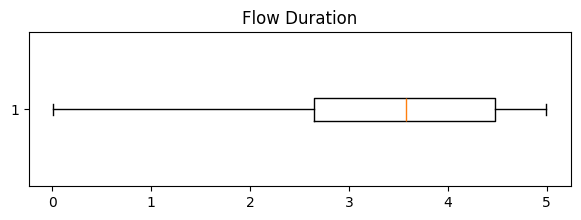

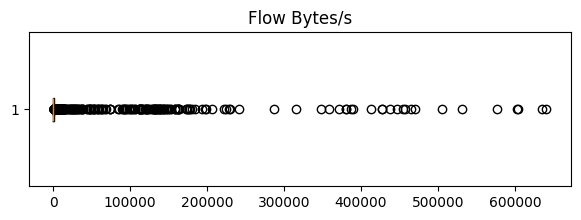

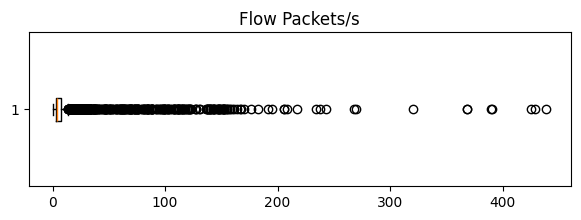

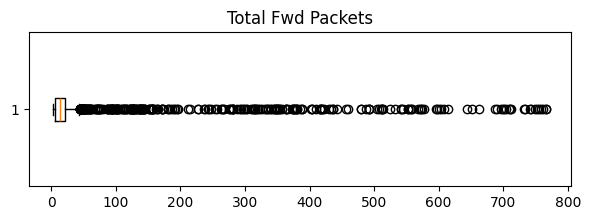

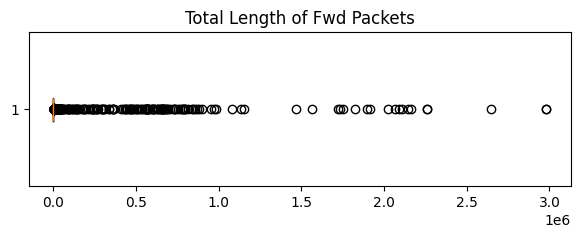

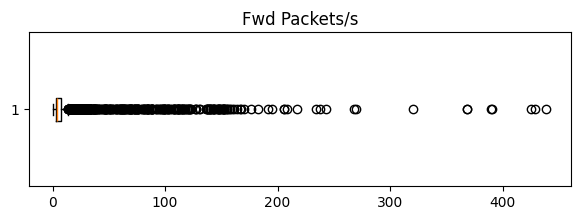

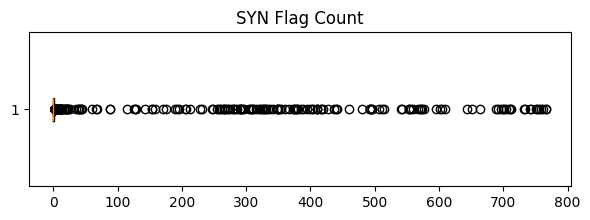

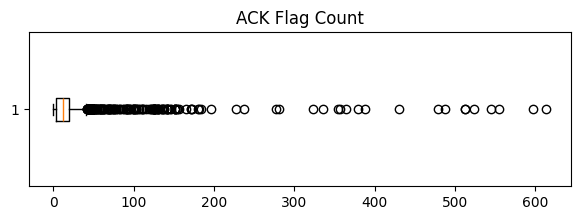

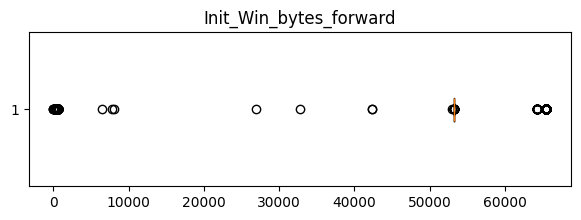

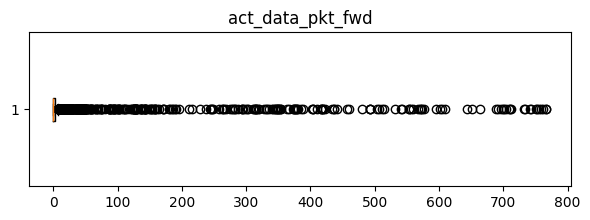

In [11]:
for col in features:

    plt.figure(figsize=(7,2))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

In [12]:
df[features].var().sort_values()

Flow Duration                  1.878857e+00
Flow Packets/s                 1.521633e+03
Fwd Packets/s                  1.521633e+03
ACK Flag Count                 2.101587e+03
SYN Flag Count                 1.130972e+04
act_data_pkt_fwd               1.182185e+04
Total Fwd Packets              1.276688e+04
Init_Win_bytes_forward         5.897260e+08
Flow Bytes/s                   3.001125e+09
Total Length of Fwd Packets    5.148819e+10
dtype: float64

In [13]:
for col in features:

    print(col)

    print(df[col].nunique())

    print()

Flow Duration
2328

Flow Bytes/s
2328

Flow Packets/s
2328

Total Fwd Packets
260

Total Length of Fwd Packets
727

Fwd Packets/s
2328

SYN Flag Count
150

ACK Flag Count
144

Init_Win_bytes_forward
30

act_data_pkt_fwd
235



In [14]:
for col in features:

    print(col)

    print(df[col].std())

    print()

Flow Duration
1.3707142145266562

Flow Bytes/s
54782.52912618797

Flow Packets/s
39.008109589118504

Total Fwd Packets
112.99059765395602

Total Length of Fwd Packets
226910.0896003305

Fwd Packets/s
39.008109589118504

SYN Flag Count
106.34716369481997

ACK Flag Count
45.84307097372524

Init_Win_bytes_forward
24284.274693936142

act_data_pkt_fwd
108.72835153109398



In [15]:
from scipy.stats import entropy

In [16]:
for col in features:

    counts = df[col].value_counts()

    e = entropy(counts)

    print(col,e)

Flow Duration 7.752764808851328
Flow Bytes/s 7.752764808851328
Flow Packets/s 7.752764808851328
Total Fwd Packets 3.7900278925972875
Total Length of Fwd Packets 5.208937634863059
Fwd Packets/s 7.752764808851328
SYN Flag Count 1.319055474583712
ACK Flag Count 3.554980762476407
Init_Win_bytes_forward 1.6702315963392333
act_data_pkt_fwd 1.876231172494852


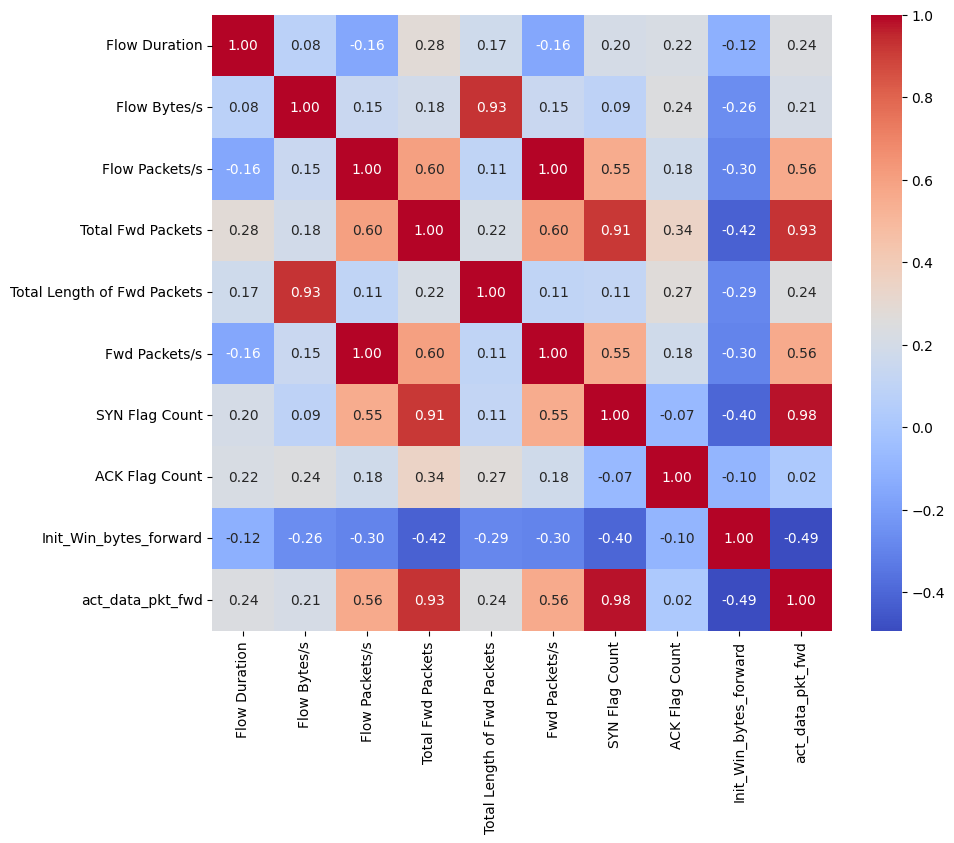

In [17]:
corr = df[features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(

corr,

annot=True,

fmt=".2f",

cmap="coolwarm"

)

plt.show()

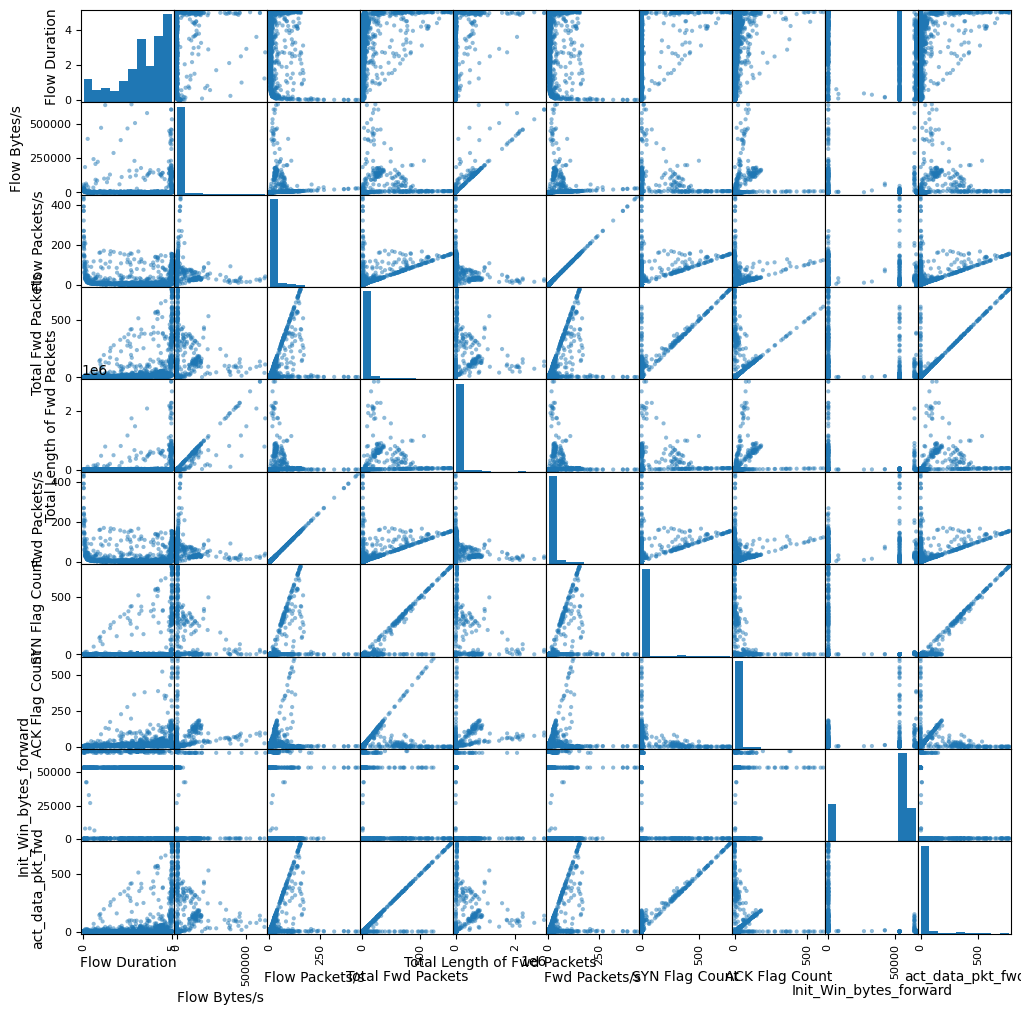

In [18]:
from pandas.plotting import scatter_matrix

scatter_matrix(

df[features],

figsize=(12,12),

diagonal='hist'

)

plt.show()

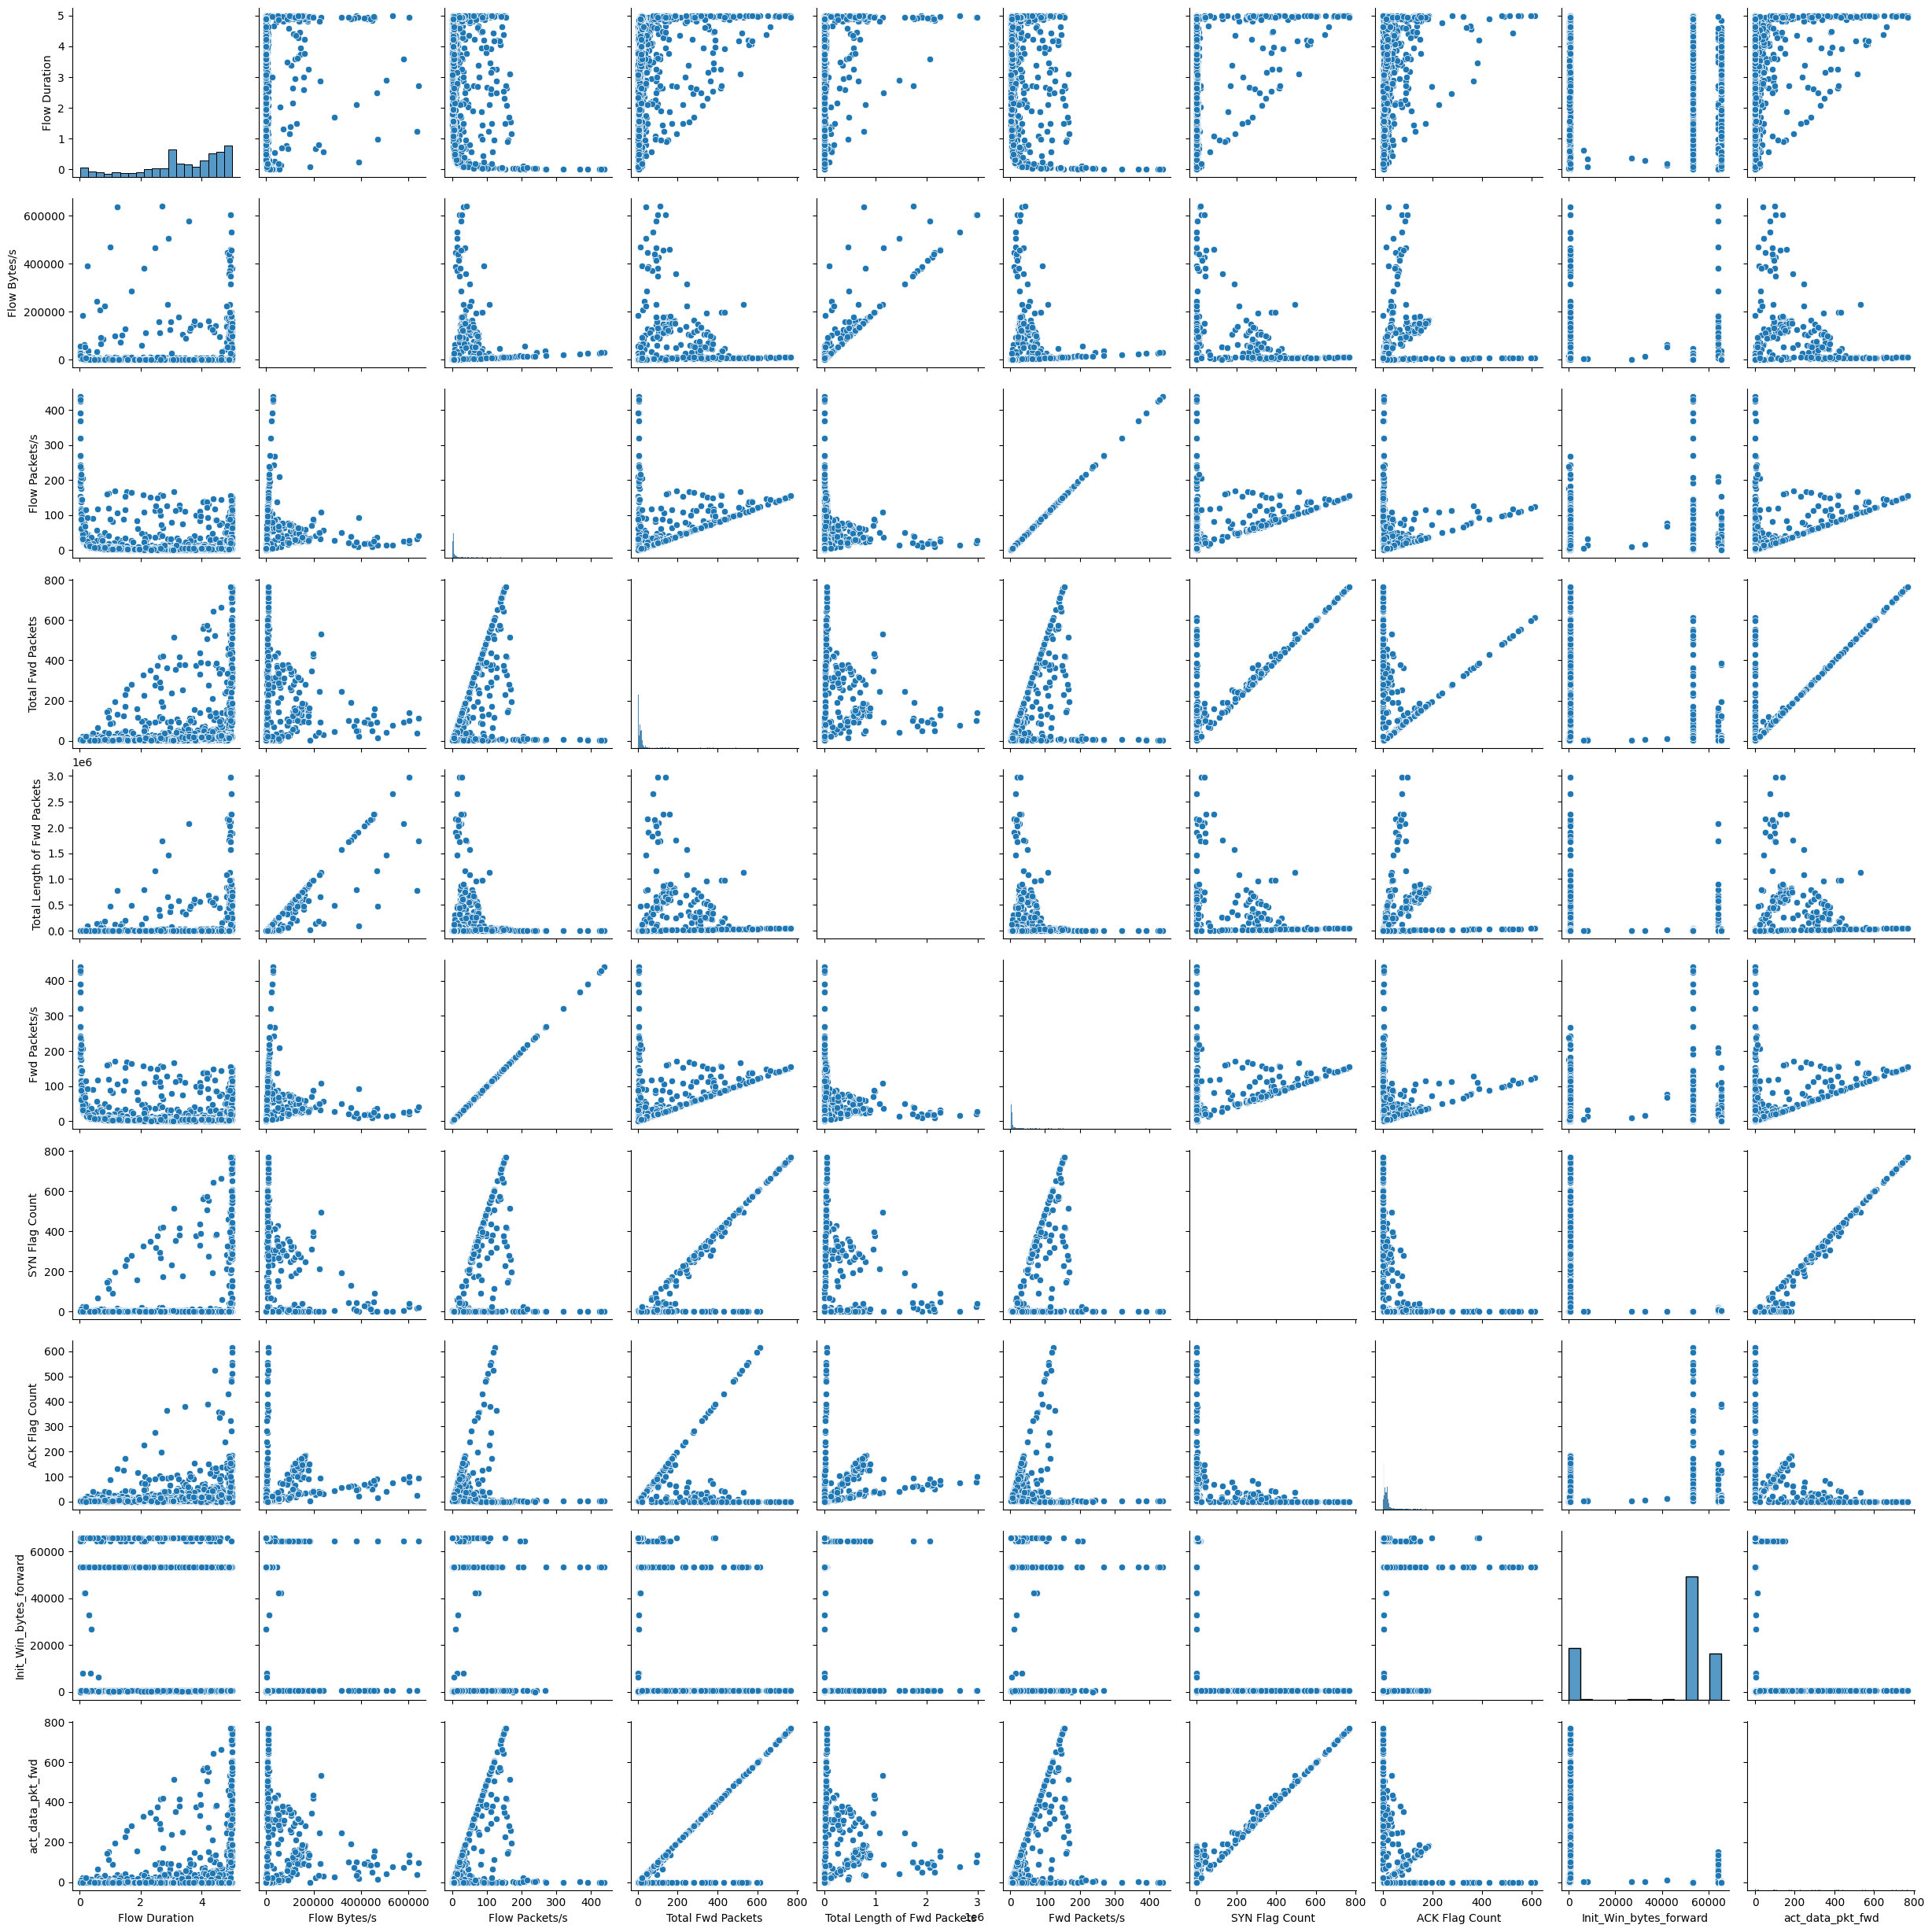

In [19]:
sns.pairplot(df[features])

plt.show()

In [20]:
corr = abs(df[features].corr())

corr

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packets/s,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,act_data_pkt_fwd
Flow Duration,1.000000,0.081858,0.157865,0.282024,0.173901,0.157865,0.203829,0.220055,0.116466,0.238714
Flow Bytes/s,0.081858,1.000000,0.145521,0.184952,0.927333,0.145521,0.090119,0.244820,0.264872,0.208360
Flow Packets/s,0.157865,0.145521,1.000000,0.597787,0.106833,1.000000,0.554683,0.181452,0.295982,0.558617
Total Fwd Packets,0.282024,0.184952,0.597787,1.000000,0.216964,0.597787,0.913860,0.341755,0.419686,0.928817
Total Length of Fwd Packets,0.173901,0.927333,0.106833,0.216964,1.000000,0.106833,0.114933,0.266385,0.288294,0.241639
Fwd Packets/s,0.157865,0.145521,1.000000,0.597787,0.106833,1.000000,0.554683,0.181452,0.295982,0.558617
SYN Flag Count,0.203829,0.090119,0.554683,0.913860,0.114933,0.554683,1.000000,0.069140,0.400449,0.978297
ACK Flag Count,0.220055,0.244820,0.181452,0.341755,0.266385,0.181452,0.069140,1.000000,0.096586,0.017350
Init_Win_bytes_forward,0.116466,0.264872,0.295982,0.419686,0.288294,0.295982,0.400449,0.096586,1.000000,0.493637
act_data_pkt_fwd,0.238714,0.208360,0.558617,0.928817,0.241639,0.558617,0.978297,0.017350,0.493637,1.000000


In [21]:
for i in range(len(features)):

    for j in range(i+1,len(features)):

        if corr.iloc[i,j] > 0.90:

            print(

                features[i],

                "<->",

                features[j],

                corr.iloc[i,j]

            )

Flow Bytes/s <-> Total Length of Fwd Packets 0.9273327502428913
Flow Packets/s <-> Fwd Packets/s 1.0
Total Fwd Packets <-> SYN Flag Count 0.9138595947146523
Total Fwd Packets <-> act_data_pkt_fwd 0.9288165284800302
SYN Flag Count <-> act_data_pkt_fwd 0.9782967784976819


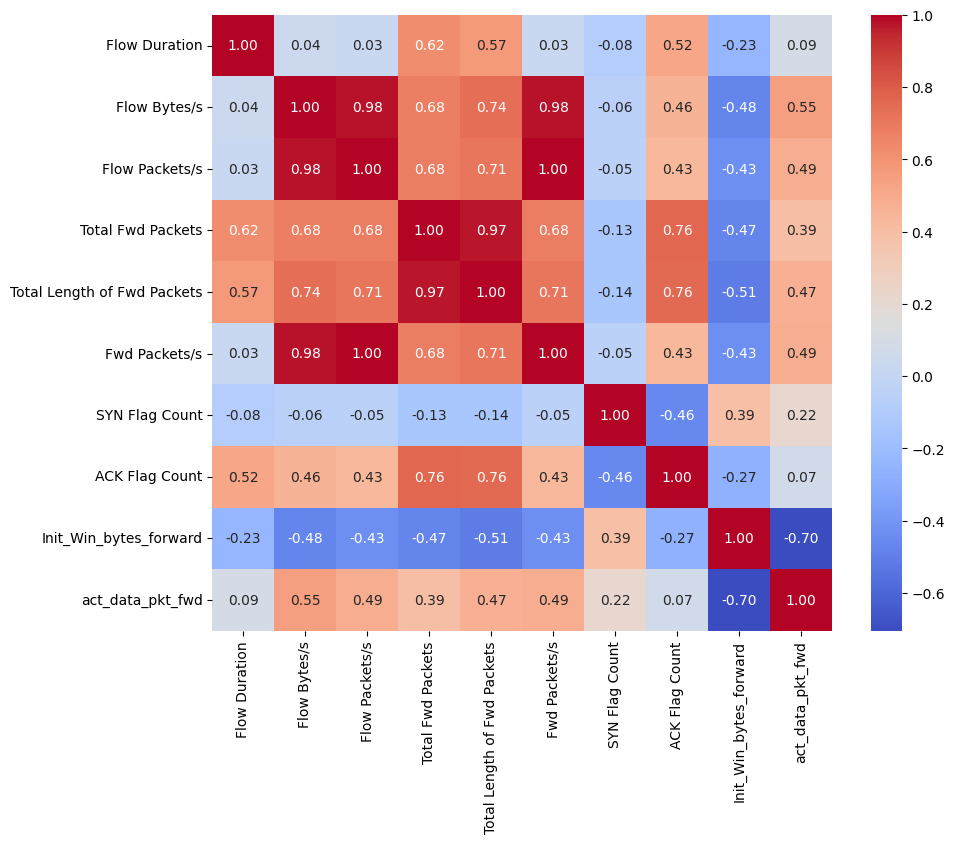

In [22]:
corr_s = df[features].corr(method='spearman')

plt.figure(figsize=(10,8))

sns.heatmap(

corr_s,

annot=True,

fmt=".2f",

cmap="coolwarm"

)

plt.show()